# Factorial control simulation: shock-cue speed x motivational importance (MI)

3 (speed) x 5 (MI) design:

| file | speed | MI |
|---|---|---|
| `lap_4_speed_0.5_MI_1.npz`  | 0.5 | 1  |
| `lap_4_speed_0.5_MI_3.npz`  | 0.5 | 3  |
| `lap_4_speed_0.5_MI_5.npz`  | 0.5 | 5  |
| `lap_4_speed_0.5_MI_7.npz`  | 0.5 | 7  |
| `lap_4_speed_0.5_MI_10.npz` | 0.5 | 10 |
| `lap_4_speed_1_MI_1.npz`    | 1.0 | 1  |
| `lap_4_speed_1_MI_3.npz`    | 1.0 | 3  |
| `lap_4_speed_1_MI_5.npz`    | 1.0 | 5  |
| `lap_4_speed_1_MI_7.npz`    | 1.0 | 7  |
| `lap_4_speed_1_MI_10.npz`   | 1.0 | 10 |
| `lap_4_speed_2_MI_1.npz`    | 2.0 | 1  |
| `lap_4_speed_2_MI_3.npz`    | 2.0 | 3  |
| `lap_4_speed_2_MI_5.npz`    | 2.0 | 5  |
| `lap_4_speed_2_MI_7.npz`    | 2.0 | 7  |
| `lap_4_speed_2_MI_10.npz`   | 2.0 | 10 |

### Setup

In [1]:
import os, sys, pickle, time
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from tqdm import tqdm


In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
sys.path.insert(0, os.path.join(base_path, "code/functions"))

from global_variables import *
from linear_shock_variables import *
from linear_shock_functions import sample_spatial_points, get_tuning_curve, load_PF_starts, compute_transition_matrix
from common_functions import input_driven_rate, find_PF_peak, save_place_fields, behavior_markov
from plots import *
from stat_functions import *

data_path = os.path.join(base_path, "results", "factorial_control")
plot_path = os.path.join(data_path, "plots")
external_data_root = os.path.join(base_path, "results", "linear_shock")
os.makedirs(plot_path, exist_ok=True)

folder_root = "trial"
trial_number = 10                     # shock_exposure0..9, each with all 15 (speed, MI) scenario files
target_seed = np.arange(trial_number)
save_plot = False


### Scenario definitions

`feat_state = num_state_total - 1` (state 8 on 1-indexed plot axes) is the
0-indexed state where the shock cue is introduced
(`linear_shock_variables.feature_unit_ID[1][0]`), and `feat_idx = 1` is its
feature channel within `MI_vector` / `feature_speed` / `error_list`'s
columns (matching the convention used in `analyze_linear_shock.ipynb`).
`before_label` (`simul_trial_3_exp`) is the checkpoint common to all 15
scenarios, captured at the end of lap 3, before the shock cue is ever
encountered; it lives under `external_data_root` rather than `data_path`.


In [4]:
target_speed = [0.5, 1.0, 2.0]     # slower, control, and faster (default avoidance) through the shock state
target_MI = [1, 3, 5, 7, 10]       # MI=1, MI=3, MI=5, MI=7, and MI=10 (default)

speed_style = {0.5: ("slow", "blue"), 1.0: ("standard", "black"), 2.0: ("fast", "red")}

scenario_file = {(sp, mi): "lap_4_speed_%g_MI_%g" % (sp, mi)
                  for sp in target_speed for mi in target_MI}
scenarios = list(scenario_file.keys())

feat_state = num_state_total - 1  # 0-indexed shock state (state 8 on 1-indexed plot axes)
feat_idx = 1                      # shock-cue channel in MI_vector / feature_speed / error_list
before_label = "lap_3"

all_labels = [before_label] + list(scenario_file.values())
print("%d conditions per trial:" % len(all_labels), all_labels)

def load_npz(label, seed):
    """Load one scenario's (or the shared before-checkpoint's) saved npz for `seed`."""
    foldername = folder_root + str(seed)
    root = external_data_root if label == before_label else data_path
    return np.load(os.path.join(root, foldername, label + ".npz"))


16 conditions per trial: ['lap_3', 'lap_4_speed_0.5_MI_1', 'lap_4_speed_0.5_MI_3', 'lap_4_speed_0.5_MI_5', 'lap_4_speed_0.5_MI_7', 'lap_4_speed_0.5_MI_10', 'lap_4_speed_1_MI_1', 'lap_4_speed_1_MI_3', 'lap_4_speed_1_MI_5', 'lap_4_speed_1_MI_7', 'lap_4_speed_1_MI_10', 'lap_4_speed_2_MI_1', 'lap_4_speed_2_MI_3', 'lap_4_speed_2_MI_5', 'lap_4_speed_2_MI_7', 'lap_4_speed_2_MI_10']


In [5]:
def plot_speed_mi_line(ax, data_by_scenario):
    """Line plot over the (speed, MI) grid: mean +/- std per speed group,
    with round markers at each MI's true numeric value on the x-axis (so
    spacing reflects the real, unevenly-spaced MI values, e.g. 1, 3, 5, 7, 10)."""
    mi_arr = np.array(target_MI, dtype=float)
    for sp in target_speed:
        label, color = speed_style[sp]
        mean_v = np.array([data_by_scenario[(sp, mi)].mean() for mi in target_MI])
        sd_v = np.array([data_by_scenario[(sp, mi)].std() for mi in target_MI])
        ax.plot(mi_arr, mean_v, marker='o', color=color, label=label)
        ax.fill_between(mi_arr, mean_v - sd_v, mean_v + sd_v, color=color, alpha=0.2, linewidth=0)
    ax.set_xticks(mi_arr); ax.set_xticklabels(["MI=%g" % mi for mi in target_MI])
    ax.set_xlabel("Motivational importance")

In [6]:
def plot_speed_mi_box(ax, data_by_scenario, box_width=0.22, connect=True):
    """Grouped box plot over the (speed, MI) grid: one box per speed at each MI
    tick (evenly spaced, labeled by true MI value), with a line connecting the
    medians of each speed group across MI. Returns legend handles (one Patch
    per speed) for the caller to pass to ax.legend(handles=...)."""
    xx = np.arange(len(target_MI))
    offsets = {0.5: -box_width, 1.0: 0.0, 2.0: box_width}
    for sp in target_speed:
        _, color = speed_style[sp]
        data = [data_by_scenario[(sp, mi)] for mi in target_MI]
        positions = xx + offsets[sp]
        bp = ax.boxplot(data, positions=positions, widths=box_width * 0.9,
                         patch_artist=True, showfliers=False)
        for box in bp['boxes']:
            box.set(facecolor=color, alpha=0.35, edgecolor=color)
        for key in ['whiskers', 'caps', 'medians']:
            for line in bp[key]:
                line.set(color=color)
        if connect:
            ax.plot(positions, [np.median(d) for d in data], color=color,
                    marker='o', markersize=3, linewidth=1.2, zorder=3)

    ax.set_xticks(xx); ax.set_xticklabels(["MI=%g" % mi for mi in target_MI])
    ax.set_xlim(xx[0] - 0.5, xx[-1] + 0.5)
    ax.set_xlabel("Motivational importance")
    return [plt.matplotlib.patches.Patch(facecolor=speed_style[sp][1], alpha=0.35,
                                          edgecolor=speed_style[sp][1], label=speed_style[sp][0])
            for sp in target_speed]


## 1. Detect CA1 place cells & simulate CA1 activity

Mirrors `find_place_cells` in `run_online.py`: for each saved weight
snapshot, sweep `sample_spatial_points(unit_gran)` across the track, drive
CA1 with the stored `w_CA3_CA1` via `input_driven_rate(..., rate_shift=5)`
(matching that function's call exactly), and label neurons whose peak rate
exceeds `place_thr_FR` as place cells. Results are cached per (trial,
condition) under `activity/` and `detected_PC/` inside each trial folder
(under `data_path`, even for the externally-sourced `before_label`).


In [30]:
def detect_place_cells_and_activity(w_CA3_CA1, place_peak_position, CA3_phi_list):
    """Return (CA1_activity, CA1_place_fields dict) for one weight snapshot."""
    CA1_activity = np.zeros((place_peak_position.shape[0], num_CA1_neurons))
    for ll in range(place_peak_position.shape[0]):
        position = place_peak_position[ll]
        CA3_FR = get_tuning_curve(position, CA3_phi_list) * infield_rate * theta_mod_factor
        CA1_activity[ll, :] = input_driven_rate(np.arange(num_CA1_neurons), CA3_FR, w_CA3_CA1, rate_shift=5)

    place_cell_idx = np.where(np.max(CA1_activity, axis=0) >= place_thr_FR)[0]
    place_peak_idx = find_PF_peak(CA1_activity)
    CA1_place_fields = {nid: np.array(place_peak_position[place_peak_idx[nid]]) for nid in place_cell_idx}
    return CA1_activity, CA1_place_fields


In [34]:
place_peak_position = sample_spatial_points(unit_gran)
CA3_place_fields = load_PF_starts()
CA3_phi_list = list(CA3_place_fields.values())
print("place_peak_position:", place_peak_position.shape, " CA3 place fields:", len(CA3_place_fields))

t0 = time.time()
for seed in tqdm(target_seed):
    foldername = folder_root + str(seed)
    act_dir = os.path.join(data_path, foldername, "activity")
    pc_dir = os.path.join(data_path, foldername, "detected_PC")
    os.makedirs(act_dir, exist_ok=True)
    os.makedirs(pc_dir, exist_ok=True)

    for label in all_labels:
        w_CA3_CA1 = load_npz(label, seed)["w_CA3_CA1"]
        CA1_activity, CA1_place_fields = detect_place_cells_and_activity(w_CA3_CA1, place_peak_position, CA3_phi_list)

        np.savez_compressed(os.path.join(act_dir, "CA1_activity_%s.npz" % label),
                             CA1_activity=CA1_activity, place_thr_FR=place_thr_FR, unit_gran=unit_gran)
        save_place_fields(CA1_place_fields, os.path.join(pc_dir, "CA1_%s.pkl" % label))

print("done in %.1f s" % (time.time() - t0))


place_peak_position: (32, 2)  CA3 place fields: 3200


  0%|          | 0/10 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [11]:
# Sanity check: place-cell count should grow with MI/slower speed (more plateau potentials at the salient state)
seed0_dir = os.path.join(data_path, folder_root + str(target_seed[0]), "detected_PC")
for label in all_labels:
    pf = load_PF_starts(os.path.join(seed0_dir, "CA1_PF_%s.pkl" % label))
    print("%-28s n_place_cells=%d" % (label, len(pf)))


simul_trial_3_exp            n_place_cells=219
lap_4_speed_0.5_MI_1         n_place_cells=1585
lap_4_speed_0.5_MI_4         n_place_cells=1830
lap_4_speed_0.5_MI_7         n_place_cells=1823
lap_4_speed_0.5_MI_10        n_place_cells=1938
lap_4_speed_1_MI_1           n_place_cells=1566
lap_4_speed_1_MI_4           n_place_cells=1799
lap_4_speed_1_MI_7           n_place_cells=1831
lap_4_speed_1_MI_10          n_place_cells=1898
lap_4_speed_2_MI_1           n_place_cells=1584
lap_4_speed_2_MI_4           n_place_cells=1799
lap_4_speed_2_MI_7           n_place_cells=1832
lap_4_speed_2_MI_10          n_place_cells=1832


## 2. Perceived salience (PS) at the salient state vs. other states

`PS_list` holds the per-100&nbsp;ms-bin perceived salience across the full
lap-4 (states 0-7). Each non-salient state occupies `steps_per_unit` (10)
bins; the salient state's window has `round(steps_per_unit / speed)` bins
(longer at slower speeds). Same comparison as `analyze_linear_shock.ipynb`'s
Fig. 6c panel, now split across the speed x MI grid instead of across laps.


In [7]:
def state_window_bounds(speed):
    dwell = int(round(steps_per_unit / speed))
    start = feat_state * steps_per_unit
    return start, start + dwell

def PS_state_vs_others(label, seed, speed, target_length=None):
    PS_list = load_npz(label, seed)["PS_list"]
    if target_length is None:
        lo, hi = state_window_bounds(speed)
    else:
        lo, hi = feat_state * steps_per_unit, feat_state * steps_per_unit+target_length
    state_val = PS_list[lo:hi].mean()
    others_val = np.concatenate([PS_list[:lo], PS_list[hi:]]).mean()
    return state_val, others_val

PS_state = {}; PS_others = {}; target_length = 5
for sp, mi in scenarios:
    label = scenario_file[(sp, mi)]
    vals = [PS_state_vs_others(label, s, sp, target_length) for s in target_seed]
    PS_state[(sp, mi)] = np.array([v[0] for v in vals])
    PS_others[(sp, mi)] = np.array([v[1] for v in vals])

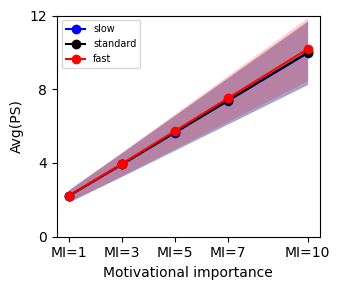

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
others_mean = np.mean([PS_others[(sp, mi)].mean() for sp, mi in scenarios])
# ax.axhline(others_mean, color='grey', linestyle='--', linewidth=0.8, label="others")
plot_speed_mi_line(ax, PS_state)
ax.legend(fontsize=7)
ax.set_ylabel("Avg(PS)"); ax.set_ylim(0,12); ax.set_yticks(np.arange(0, 13, 4))
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "PS_salient_vs_others.png"), dpi=300)
plt.show()

In [9]:
# Two-way ANOVA on the decay rate `a`: does speed and MI each have an effect
# independent of the other (main effects), beyond any speed x MI interaction?
target_df = pd.DataFrame([
    {"speed": "x%g" % sp, "MI": "MI%g" % mi, "seed": s, "data": data}
    for sp, mi in scenarios
    for s, data in zip(target_seed, PS_state[(sp, mi)])
])

target_anova = anova_lm(smf.ols("data ~ C(speed) * C(MI)", data=target_df).fit(), typ=2)

def eta_squared(anova_table):
    ss = anova_table["sum_sq"]
    return ss / (ss.sum())

target_anova["eta_sq"] = eta_squared(target_anova)
print(target_anova.round(4))
print()
for term in ["C(speed)", "C(MI)", "C(speed):C(MI)"]:
    row = target_anova.loc[term]
    print(f"{term:18s} F({row['df']:.0f}, {target_anova.loc['Residual', 'df']:.0f})={row['F']:.3f}, "
          f"p={row['PR(>F)']:.4g}, eta^2={row['eta_sq']:.3f}")


                   sum_sq     df         F  PR(>F)  eta_sq
C(speed)           0.2851    2.0    0.1080  0.8977  0.0002
C(MI)           1107.6275    4.0  209.8144  0.0000  0.8611
C(speed):C(MI)     0.1670    8.0    0.0158  1.0000  0.0001
Residual         178.1690  135.0       NaN     NaN  0.1385

C(speed)           F(2, 135)=0.108, p=0.8977, eta^2=0.000
C(MI)              F(4, 135)=209.814, p=6.823e-57, eta^2=0.861
C(speed):C(MI)     F(8, 135)=0.016, p=1, eta^2=0.000


## 3. CA3->CA1 weight strength at the salient state: before vs. after

Overrepresentation index = mean weight onto CA1 from the salient state's CA3
block, divided by the mean weight over the whole `w_CA3_CA1` matrix. "Before"
is the shared `before_label` checkpoint (identical across all 15 scenarios
per trial, sourced from `external_data_root`); "after" is each scenario's
completed lap 4.


In [10]:
cpu = num_CA3_neurons // num_state_total  # CA3 cells per state

def weight_overrep(label, seed, state):
    w = load_npz(label, seed)["w_CA3_CA1"]
    state_block = w[state * cpu:(state + 1) * cpu, :]
    return state_block.mean() / (w.mean() + 1e-12)

overrep_before = np.array([weight_overrep(before_label, s, feat_state) for s in target_seed])
overrep_after = {}
for sp, mi in scenarios:
    overrep_after[(sp, mi)] = np.array([weight_overrep(scenario_file[(sp, mi)], s, feat_state) for s in target_seed])

print("Before passage, overrep = %.4f +/- %.4f" % (overrep_before.mean(), overrep_before.std()))


Before passage, overrep = 1.0091 +/- 0.0811


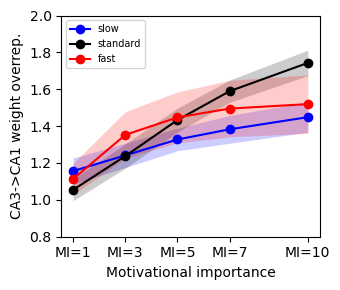

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
plot_speed_mi_line(ax, overrep_after)
ax.legend(fontsize=7)
ax.set_ylabel("CA3->CA1 weight overrep."); ax.set_ylim(0.8,2.0)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "weight_overrep_before_after.png"), dpi=300)
plt.show()

In [12]:
import pandas as pd
# Two-way ANOVA on the decay rate `a`: does speed and MI each have an effect
# independent of the other (main effects), beyond any speed x MI interaction?
target_df = pd.DataFrame([
    {"speed": "x%g" % sp, "MI": "MI%g" % mi, "seed": s, "data": data}
    for sp, mi in scenarios
    for s, data in zip(target_seed, overrep_after[(sp, mi)])
])

target_anova = anova_lm(smf.ols("data ~ C(speed) * C(MI)", data=target_df).fit(), typ=2)

def eta_squared(anova_table):
    ss = anova_table["sum_sq"]
    return ss / (ss.sum())

target_anova["eta_sq"] = eta_squared(target_anova)
print(target_anova.round(4))
print()
for term in ["C(speed)", "C(MI)", "C(speed):C(MI)"]:
    row = target_anova.loc[term]
    print(f"{term:18s} F({row['df']:.0f}, {target_anova.loc['Residual', 'df']:.0f})={row['F']:.3f}, "
          f"p={row['PR(>F)']:.4g}, eta^2={row['eta_sq']:.3f}")


                sum_sq     df        F  PR(>F)  eta_sq
C(speed)        0.2704    2.0  13.3494     0.0  0.0432
C(MI)           3.9784    4.0  98.2016     0.0  0.6360
C(speed):C(MI)  0.6392    8.0   7.8889     0.0  0.1022
Residual        1.3673  135.0      NaN     NaN  0.2186

C(speed)           F(2, 135)=13.349, p=5.126e-06, eta^2=0.043
C(MI)              F(4, 135)=98.202, p=5.496e-39, eta^2=0.636
C(speed):C(MI)     F(8, 135)=7.889, p=1.134e-08, eta^2=0.102


## 4. Place-cell overrepresentation at the salient state

For every trial x condition, the fraction of detected CA1 place cells whose
field falls in state 8 (`feat_state`) is compared against the uniform
expectation `1/num_state_total` (one-sample, one-tailed t-test, as in
`analyze_linear_shock.ipynb`), then compared across the speed x MI grid.


In [13]:
def place_cell_fraction_at_state(label, seed, state):
    if label == before_label: root = external_data_root
    else: root = data_path
    pc_dir = os.path.join(root, folder_root + str(seed), "detected_PC")
    CA1_PF = load_PF_starts(os.path.join(pc_dir, "CA1_%s.pkl" % label))
    if len(CA1_PF) == 0:
        return 0.0
    states = np.array([int(pos[1]) for pos in CA1_PF.values()])
    return np.mean(states == state)

PC_frac_before = np.array([place_cell_fraction_at_state(before_label, s, feat_state) for s in target_seed])
PC_frac = {}
for sp, mi in scenarios:
    label = scenario_file[(sp, mi)]
    PC_frac[(sp, mi)] = np.array([place_cell_fraction_at_state(label, s, feat_state) for s in target_seed])

mu0 = 1.0 / num_state_total
print("Uniform expectation: %.4f" % mu0)
print("Before passage (lap 3): %.4f +/- %.4f" % (PC_frac_before.mean(), PC_frac_before.std()))


Uniform expectation: 0.1250
Before passage (lap 3): 0.1929 +/- 0.0280


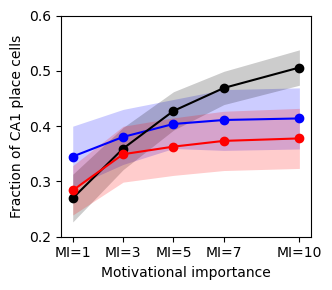

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
plot_speed_mi_line(ax, PC_frac)
# ax.legend(fontsize=7)
ax.set_ylabel("Fraction of CA1 place cells"); ax.set_ylim(0.2,0.6)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "PC_overrep_salient_state.png"), dpi=300)
plt.show()

In [15]:
# Two-way ANOVA on the decay rate `a`: does speed and MI each have an effect
# independent of the other (main effects), beyond any speed x MI interaction?
target_df = pd.DataFrame([
    {"speed": "x%g" % sp, "MI": "MI%g" % mi, "seed": s, "data": data}
    for sp, mi in scenarios
    for s, data in zip(target_seed, PC_frac[(sp, mi)])
])

target_anova = anova_lm(smf.ols("data ~ C(speed) * C(MI)", data=target_df).fit(), typ=2)

def eta_squared(anova_table):
    ss = anova_table["sum_sq"]
    return ss / (ss.sum())

target_anova["eta_sq"] = eta_squared(target_anova)
print(target_anova.round(4))
print()
for term in ["C(speed)", "C(MI)", "C(speed):C(MI)"]:
    row = target_anova.loc[term]
    print(f"{term:18s} F({row['df']:.0f}, {target_anova.loc['Residual', 'df']:.0f})={row['F']:.3f}, "
          f"p={row['PR(>F)']:.4g}, eta^2={row['eta_sq']:.3f}")


                sum_sq     df        F  PR(>F)  eta_sq
C(speed)        0.0866    2.0  17.6940     0.0  0.1007
C(MI)           0.3375    4.0  34.4909     0.0  0.3925
C(speed):C(MI)  0.1056    8.0   5.3971     0.0  0.1228
Residual        0.3303  135.0      NaN     NaN  0.3840

C(speed)           F(2, 135)=17.694, p=1.498e-07, eta^2=0.101
C(MI)              F(4, 135)=34.491, p=8.053e-20, eta^2=0.392
C(speed):C(MI)     F(8, 135)=5.397, p=6.709e-06, eta^2=0.123


## 5. Predicted presence of the shock feature at the salient state

Mirrors `analyze_linear_shock.ipynb`'s Fig. 6h panel (`CA1_activity @
w_CA1_feat`, averaged within each state's spatial samples), but restricted
to the salient state (`feat_state`) and the shock channel (`feat_idx`), and
compared across the speed x MI grid instead of across states.


In [16]:
def feat_pred_at_state(label, seed, state, feat_idx):
    act_dir = os.path.join(data_path, folder_root + str(seed), "activity")
    CA1_activity = np.load(os.path.join(act_dir, "CA1_activity_%s.npz" % label))["CA1_activity"]
    w_CA1_feat = load_npz(label, seed)["w_CA1_feat"]
    feat_pred = CA1_activity @ w_CA1_feat
    spu = CA1_activity.shape[0] // num_state_total
    return feat_pred[state * spu:(state + 1) * spu, feat_idx].mean()

feat_pred_state = {}
for sp, mi in scenarios:
    label = scenario_file[(sp, mi)]
    feat_pred_state[(sp, mi)] = np.array([feat_pred_at_state(label, s, feat_state, feat_idx) for s in target_seed])


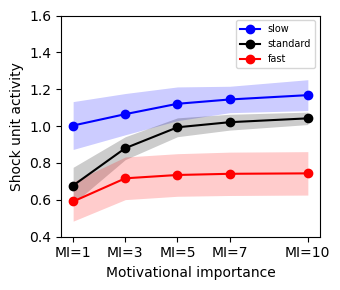

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
plot_speed_mi_line(ax, feat_pred_state)
ax.legend(fontsize=7)
ax.set_ylabel("Shock unit activity"); ax.set_ylim(0.4,1.6)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "Shock_prediction.png"), dpi=300)
plt.show()

In [18]:
# Two-way ANOVA
decay_df = pd.DataFrame([
    {"speed": "x%g" % sp, "MI": "MI%g" % mi, "seed": s, "shock_occ": a}
    for sp, mi in scenarios
    for s, a in zip(target_seed, feat_pred_state[(sp, mi)])
])

decay_anova = anova_lm(smf.ols("shock_occ ~ C(speed) * C(MI)", data=decay_df).fit(), typ=2)

def eta_squared(anova_table):
    ss = anova_table["sum_sq"]
    return ss / (ss.sum())

decay_anova["eta_sq"] = eta_squared(decay_anova)
print(decay_anova.round(4))
print()
for term in ["C(speed)", "C(MI)", "C(speed):C(MI)"]:
    row = decay_anova.loc[term]
    print(f"{term:18s} F({row['df']:.0f}, {decay_anova.loc['Residual', 'df']:.0f})={row['F']:.3f}, "
          f"p={row['PR(>F)']:.4g}, eta^2={row['eta_sq']:.3f}")


                sum_sq     df         F  PR(>F)  eta_sq
C(speed)        3.9092    2.0  195.6400  0.0000  0.6005
C(MI)           1.0332    4.0   25.8526  0.0000  0.1587
C(speed):C(MI)  0.2188    8.0    2.7381  0.0079  0.0336
Residual        1.3488  135.0       NaN     NaN  0.2072

C(speed)           F(2, 135)=195.640, p=1.304e-40, eta^2=0.600
C(MI)              F(4, 135)=25.853, p=6.445e-16, eta^2=0.159
C(speed):C(MI)     F(8, 135)=2.738, p=0.007866, eta^2=0.034


## 6. Simulated behavioral avoidance: near-shock-zone occupancy

Mirrors `analyze_linear_shock.ipynb`'s Fig. 6i-6k pipeline: the predicted
feature map at each state (`CA1_activity @ w_CA1_feat`) is converted to a
per-state value (`@ value_vector`), which parameterizes a softmax Markov
transition matrix (`compute_transition_matrix`) over the 8 states. A
100-trial, 600-step behavioral simulation (`behavior_markov`) is then run
per (trial x scenario) to estimate the fraction of time spent in the
near-shock zone (states `num_state_total//2` through `feat_state`),
compared across the speed x MI grid.


In [19]:
possible_actions = np.array([[0, -1], [0, 0], [0, 1]])  # left, stay, right
num_behav_trial = 100
total_time = 600
near_shock_lo, near_shock_hi = num_state_total // 2, feat_state

In [33]:
choice_state = 4  # 0-indexed choice-point state

def choice_point_asymmetry(label, seed, state):
    """P(go left) - P(go right) at `state`, from the same softmax transition matrix as `near_shock_occupancy`."""
    act_dir = os.path.join(data_path, folder_root + str(seed), "activity")
    CA1_activity = np.load(os.path.join(act_dir, "CA1_activity_%s.npz" % label))["CA1_activity"]
    w_CA1_feat = load_npz(label, seed)["w_CA1_feat"]
    feat_pred = CA1_activity @ w_CA1_feat
    spu = CA1_activity.shape[0] // num_state_total
    feat_pred_full = np.array([feat_pred[ss * spu:(ss + 1) * spu].mean(axis=0) for ss in range(num_state_total)])
    value_states = feat_pred_full @ value_vector
    transition_matrix, _ = compute_transition_matrix(num_state_total, value_states, possible_actions, end_state=[-1])
    return transition_matrix[state, state - 1] - transition_matrix[state, state + 1]

choice_asymmetry = {}
for sp, mi in scenarios:
    label = scenario_file[(sp, mi)]
    choice_asymmetry[(sp, mi)] = np.array([choice_point_asymmetry(label, s, choice_state) for s in target_seed])

for sp, mi in scenarios:
    vals = choice_asymmetry[(sp, mi)]
    print("speed x%-4g MI=%-4g  P(right)-P(left) @ state %d = %.4f +/- %.4f" %
          (sp, mi, choice_state, vals.mean(), vals.std()))


speed x0.5  MI=1     P(right)-P(left) @ state 4 = 0.0554 +/- 0.0217
speed x0.5  MI=3     P(right)-P(left) @ state 4 = 0.0990 +/- 0.0258
speed x0.5  MI=5     P(right)-P(left) @ state 4 = 0.1220 +/- 0.0269
speed x0.5  MI=7     P(right)-P(left) @ state 4 = 0.1356 +/- 0.0274
speed x0.5  MI=10    P(right)-P(left) @ state 4 = 0.1497 +/- 0.0276
speed x1    MI=1     P(right)-P(left) @ state 4 = 0.0473 +/- 0.0168
speed x1    MI=3     P(right)-P(left) @ state 4 = 0.0987 +/- 0.0282
speed x1    MI=5     P(right)-P(left) @ state 4 = 0.1298 +/- 0.0294
speed x1    MI=7     P(right)-P(left) @ state 4 = 0.1462 +/- 0.0284
speed x1    MI=10    P(right)-P(left) @ state 4 = 0.1599 +/- 0.0272
speed x2    MI=1     P(right)-P(left) @ state 4 = 0.0674 +/- 0.0250
speed x2    MI=3     P(right)-P(left) @ state 4 = 0.1108 +/- 0.0285
speed x2    MI=5     P(right)-P(left) @ state 4 = 0.1248 +/- 0.0295
speed x2    MI=7     P(right)-P(left) @ state 4 = 0.1295 +/- 0.0300
speed x2    MI=10    P(right)-P(left) @ state 4 

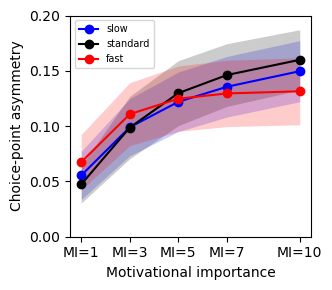

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
plot_speed_mi_line(ax, choice_asymmetry)
ax.legend(fontsize=7)
ax.set_ylabel("Choice-point asymmetry"); ax.set_ylim(0,0.2)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "choice_asymmetry.png"), dpi=300)
plt.show()

In [35]:
# Two-way ANOVA on the decay rate `a`: does speed and MI each have an effect
# independent of the other (main effects), beyond any speed x MI interaction?
decay_df = pd.DataFrame([
    {"speed": "x%g" % sp, "MI": "MI%g" % mi, "seed": s, "shock_occ": a}
    for sp, mi in scenarios
    for s, a in zip(target_seed, choice_asymmetry[(sp, mi)])
])

decay_anova = anova_lm(smf.ols("shock_occ ~ C(speed) * C(MI)", data=decay_df).fit(), typ=2)

def eta_squared(anova_table):
    ss = anova_table["sum_sq"]
    return ss / (ss.sum())

decay_anova["eta_sq"] = eta_squared(decay_anova)
print(decay_anova.round(4))
print()
for term in ["C(speed)", "C(MI)", "C(speed):C(MI)"]:
    row = decay_anova.loc[term]
    print(f"{term:18s} F({row['df']:.0f}, {decay_anova.loc['Residual', 'df']:.0f})={row['F']:.3f}, "
          f"p={row['PR(>F)']:.4g}, eta^2={row['eta_sq']:.3f}")


                sum_sq     df        F  PR(>F)  eta_sq
C(speed)        0.0005    2.0   0.3034  0.7388  0.0018
C(MI)           0.1549    4.0  47.6276  0.0000  0.5663
C(speed):C(MI)  0.0084    8.0   1.2903  0.2536  0.0307
Residual        0.1098  135.0      NaN     NaN  0.4013

C(speed)           F(2, 135)=0.303, p=0.7388, eta^2=0.002
C(MI)              F(4, 135)=47.628, p=6.411e-25, eta^2=0.566
C(speed):C(MI)     F(8, 135)=1.290, p=0.2536, eta^2=0.031


In [45]:
def near_shock_occupancy(label, seed):
    act_dir = os.path.join(data_path, folder_root + str(seed), "activity")
    CA1_activity = np.load(os.path.join(act_dir, "CA1_activity_%s.npz" % label))["CA1_activity"]
    w_CA1_feat = load_npz(label, seed)["w_CA1_feat"]
    feat_pred = CA1_activity @ w_CA1_feat
    spu = CA1_activity.shape[0] // num_state_total
    feat_pred_full = np.array([feat_pred[ss * spu:(ss + 1) * spu].mean(axis=0) for ss in range(num_state_total)])
    value_states = feat_pred_full @ value_vector
    transition_matrix, _ = compute_transition_matrix(num_state_total, value_states, possible_actions, end_state=[-1])

    occ = np.zeros(num_behav_trial)
    for tt in range(num_behav_trial):
        trajectory, _, _ = behavior_markov(transition_matrix, total_time=total_time, start_state=0, seed=1000*seed)
        occ[tt] = np.mean((trajectory >= near_shock_lo) & (trajectory <= near_shock_hi))
    return occ.mean() * 100

SH_occupancy = {}
for sp, mi in scenarios:
    label = scenario_file[(sp, mi)]
    SH_occupancy[(sp, mi)] = np.array([near_shock_occupancy(label, s) for s in target_seed])


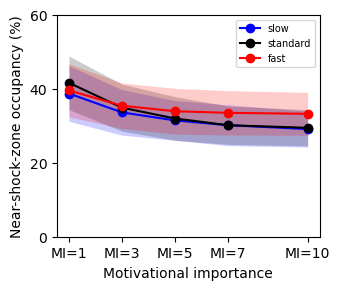

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
plot_speed_mi_line(ax, SH_occupancy)
ax.legend(fontsize=7)
ax.set_ylabel("Near-shock-zone occupancy (%)")
plt.tight_layout(); ax.set_ylim(0,60); ax.set_yticks(np.arange(0, 61, 20))
if save_plot: plt.savefig(os.path.join(plot_path, "near_shock_occupancy.svg"))
plt.show()

In [50]:
# Two-way ANOVA on the decay rate `a`: does speed and MI each have an effect
# independent of the other (main effects), beyond any speed x MI interaction?
decay_df = pd.DataFrame([
    {"speed": "x%g" % sp, "MI": "MI%g" % mi, "seed": s, "shock_occ": a}
    for sp, mi in scenarios
    for s, a in zip(target_seed, SH_occupancy[(sp, mi)])
])

decay_anova = anova_lm(smf.ols("shock_occ ~ C(speed) * C(MI)", data=decay_df).fit(), typ=2)

def eta_squared(anova_table):
    ss = anova_table["sum_sq"]
    return ss / (ss.sum())

decay_anova["eta_sq"] = eta_squared(decay_anova)
print(decay_anova.round(4))
print()
for term in ["C(speed)", "C(MI)", "C(speed):C(MI)"]:
    row = decay_anova.loc[term]
    print(f"{term:18s} F({row['df']:.0f}, {decay_anova.loc['Residual', 'df']:.0f})={row['F']:.3f}, "
          f"p={row['PR(>F)']:.4g}, eta^2={row['eta_sq']:.3f}")


                   sum_sq     df        F  PR(>F)  eta_sq
C(speed)         160.8993    2.0   1.9668  0.1439  0.0214
C(MI)           1716.6030    4.0  10.4917  0.0000  0.2285
C(speed):C(MI)   114.4581    8.0   0.3498  0.9445  0.0152
Residual        5522.0028  135.0      NaN     NaN  0.7349

C(speed)           F(2, 135)=1.967, p=0.1439, eta^2=0.021
C(MI)              F(4, 135)=10.492, p=1.974e-07, eta^2=0.228
C(speed):C(MI)     F(8, 135)=0.350, p=0.9445, eta^2=0.015
